<Figure size 1000x600 with 0 Axes>

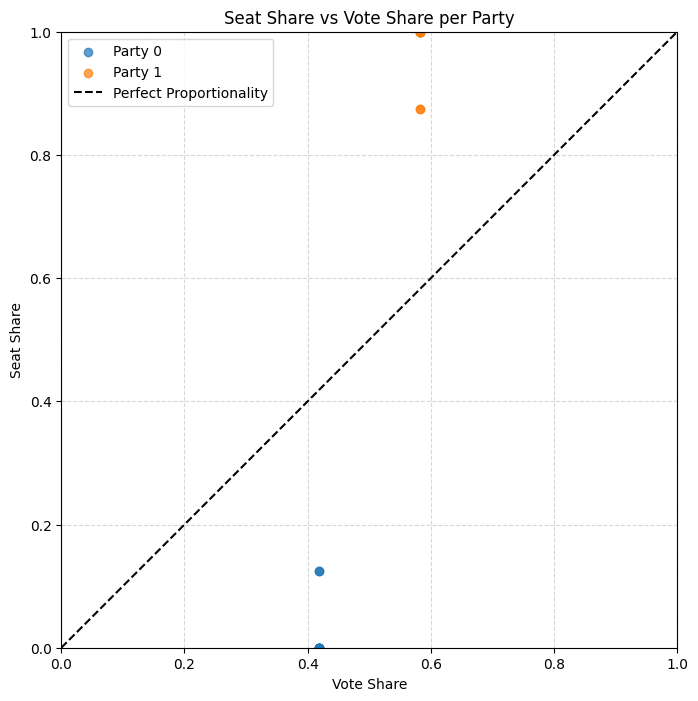


----- REDISTRICTING SUMMARY -----
Runs: 10
Mean Efficiency Gap: -0.3348
Std Efficiency Gap: 0.06991537742156585
Party 0: Mean Vote Share = 0.418, Mean Seat Share = 0.025
Party 1: Mean Vote Share = 0.582, Mean Seat Share = 0.975


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import copy
import math
import itertools
import pandas as pd
# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000       # Can change
NUM_PARTIES = 2       # Can change
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10         # Number of redistricting simulations

NUM_CITIES = 8
CITY_INTENSITY = (10, 30)
CITY_SPREAD = (20, 60)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

#-------------------------
# PARTY DISTRIBUTION (bias) - Must sum to 1 - MUST CHANGE WHEN CHANGING NUMBER OF PARTIES
# ------------------------
PARTY_BIAS = [0.45, 0.55]  

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))


# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------

voter_parties = np.random.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS )

voter_colors = party_colors[voter_parties]

def connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors=50):
#def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    # Create districts with BFS
    for d in range(num_districts):
        if not unassigned:
            break

        #seed = np.random.choice(list(unassigned))
        #seed = rng.choice(list(unassigned))
        seed = list(unassigned)[rng.integers(len(unassigned))]
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)
            #  CRITICAL FIX: RANDOMIZE GROWTH
            neighbors = rng.permutation(neighbors)
            #neighbors = list(neighbors)
            
            #rng.shuffle(neighbors)
            
            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        # Retry if district incomplete
        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            #return connected_districts(voters, num_districts, voters_per_district)
            return connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors)
    # ------------------------
    # Assign leftover voters to nearest district
    # ------------------------
    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district
# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

def efficiency_gap(district_counts):
    """
    Returns a list of efficiency gap values,
    one per district (for a single run).
    """

    district_gaps = []

    for district in district_counts:

        # Winning party
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]

        # Total votes in district
        total_votes = sum(district.values())

        # Losing votes
        num_losing_votes = total_votes - num_winning_votes

        # Wasted votes (multi-party generalization)
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes

        gap = (wasted_winner - wasted_loser) / total_votes

        district_gaps.append(gap)

    return district_gaps

def get_is_winner(district_counts, target_party):
    """
    Returns True if target_party has more votes than all others.
    If there is any tie for the maximum, the target party loses.
    """
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    
    # Target must be strictly greater than every other party
    return all(target_votes > v for v in other_votes)

def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # 1. Identify parties with votes, sorted by lowest count
            # Use party ID as a secondary sort key to handle ties consistently
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p) 
            )
            
            if active_competitors:
                # 2. Take up to (num_competitors) total votes from the lowest party first
                to_take = num_competitors
                from_party = active_competitors[0]
                
                # If the lowest doesn't have enough, we take what they have and stop 
                # (or we could cascade, but "taking from the same one" implies a single source per step)
                actual_taken = min(d[from_party], to_take)
                
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True
        
        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == NUM_DISTRICTS:
            break
            
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}

def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)
    
    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            # 1. Identify the 'Second Place' party (the strongest competitor)
            # Sort competitors by votes descending
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            
            # 2. Move votes from target to that specific strongest competitor
            to_move = min(d[target_party], num_competitors)
            
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True
        
        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins
            
        if not any_shift or new_wins == 0:
            break
            
    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}

# 1. Update your simulation functions to return the current vote share
def get_current_vote_share(district_counts, target_party):
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

# 2. Updated compute function
def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    # Calculate starting state
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))
    
    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    # Base point is the current status of the party
    base_point = (initial_vote, initial_wins)

    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    merged = sorted(set(fwd_points + rev_points))
    return merged
#3. Updated plotting function to show both curves
def plot_step_and_complement(step_points, NUM_DISTRICTS, title="Seat–Vote Curve"):
    x, y = zip(*sorted(step_points))
    x, y = np.array(x), np.array(y)

    # Convert district counts to seat share (0–1)
    y = y / NUM_DISTRICTS

    plt.figure(figsize=(8, 6))
    
    # Original curve
    plt.step(x, y, where="post", color="black", label="Seat–Vote Curve", lw=2)

    # Complement curve: (1-x, 1-y)
    xc = 1 - x
    yc = 1 - y
    
    # Sort for proper plotting
    order = np.argsort(xc)
    plt.step(xc[order], yc[order], where="post",
             color="blue", linestyle="--", label="Complement Curve")

    plt.xlabel("Statewide Vote Share")
    plt.ylabel("Seat Share")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()    

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat–vote curve (as seat share 0–1)
    and its complement curve.

    Parameters:
        step_points: list of (vote_share, districts_won) tuples
        num_districts: total number of districts

    Returns:
        Dictionary with:
            - area_between
            - area_step
            - area_complement
    """
    # Sort points by vote share
    points = sorted(step_points, key=lambda x: x[0])
    
    # Ensure endpoints at 0 and 1
    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]
    
    # Convert to numpy arrays
    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts   # Normalize to 0–1 seat share

    # Complement curve: g(x) = 1 - f(1-x)
    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]

    # Combine all x-breakpoints
    all_x = np.unique(np.concatenate([step_x, complement_x]))
    
    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        idx = max(0, idx)
        return ys[idx]

    for i in range(len(all_x) - 1):
        x1 = all_x[i]
        x2 = all_x[i + 1]
        width = x2 - x1

        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)

        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {
        "area_between": area_between,
        "area_step": area_step,
        "area_complement": area_complement
    }
import itertools

def compute_pairwise_area(curve1, curve2, num_districts):
    """
    Computes the absolute area between the step curves of two different parties.
    """
    # 1. Normalize and Sort
    # curve format: [(vote_share, districts_won), ...]
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    
    # Seat shares (0 to 1)
    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    # 2. Find every unique x-coordinate where either curve changes
    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0: all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1: all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    # 3. Integrate absolute difference
    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff
        
    return total_area
# ------------------------
# RUN SIMULATIONS
# ------------------------
all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []       # Party 0 only, optional
all_seat_shares = []       # Party 0 only, optional
all_pr_vote_shares = []    # dict of all parties
all_pr_seat_shares = []    # dict of all parties
all_district_counts = []    # For potential further analysis
all_area_results = []    # For step function area analysis
all_step_curves = []       # Store step curves for potential plotting
plt.figure(figsize=(10,6))


'''    
for run in range(NUM_RUNS):
    district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)
    district_counts = count_votes(district_labels)
'''
for run in range(NUM_RUNS):

    rng = np.random.default_rng(run)

    district_labels = connected_districts(
        voters,
        NUM_DISTRICTS,
        VOTERS_PER_DISTRICT,
        rng
    )

    district_counts = count_votes(district_labels)
# Efficiency gap
    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    # ------------------------
    # Proportional Representation (all parties)
    # ------------------------
    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    # Normalize vote share
    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    # Seat share
    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)
    all_district_counts.append(district_counts)
    # -----------------------------------------
# STEP CURVES FOR EACH PARTY (per simulation)
# -----------------------------------------

    step_curves_this_run = {}
    area_results_this_run = {}

    for party in PARTY_IDS:
        curve = compute_step_curve_for_party(
            district_counts,
            party,
            PARTY_IDS,
            NUM_DISTRICTS
        )
        step_curves_this_run[party] = curve
        area_metrics = compute_step_function_area(curve, NUM_DISTRICTS)
        area_results_this_run[party] = area_metrics

# Store all curves for this simulation
    all_step_curves.append(step_curves_this_run)
    all_area_results.append(area_results_this_run)


def export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS, filename="gerrymandering_data.xlsx"):
    print(f"Gathering data for {len(all_district_counts)} runs...")
   
    # --- SHEET 1: DISTRICT LEVEL WINNERS & COUNTS ---
    # Good for: Seeing exactly which districts flipped and by how much
    dist_rows = []
    for run_idx, run_counts in enumerate(all_district_counts):
        for dist_idx, counts in enumerate(run_counts):
            winner = max(counts, key=counts.get)
            row = {
                "Run": run_idx + 1,
                "District": dist_idx + 1,
                "Winner": winner
            }
            # Add raw counts for every party
            for party in PARTY_IDS:
                row[f"{party}_Votes"] = counts[party]
            dist_rows.append(row)
    df_districts = pd.DataFrame(dist_rows)

    # --- SHEET 2: PAIRWISE AREA DIFFERENCES ---
    # Good for: Measuring structural bias between specific party pairs
    pair_rows = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
            pair_rows.append({
                "Run": run_idx + 1,
                "Comparison": f"{p1} vs {p2}",
                "Area_Gap": gap
            })
    df_areas = pd.DataFrame(pair_rows)

    # --- SHEET 3: EFFICIENCY GAPS ---
    # Good for: Standard partisan symmetry metrics
    # (Using the dynamic threshold logic we built earlier)
    gap_rows = []
    for run_idx, district_counts in enumerate(all_district_counts):
        wasted_votes = {p: 0 for p in PARTY_IDS}
        total_v = 0
        for d in district_counts:
            d_total = sum(d.values())
            total_v += d_total
            sorted_v = sorted(d.values(), reverse=True)
            winner_p = max(d, key=d.get)
            needed = sorted_v[1] + 1 if len(sorted_v) > 1 else (d_total // 2) + 1
           
            for p in PARTY_IDS:
                wasted_votes[p] += (max(0, d[p] - needed) if p == winner_p else d[p])
       
        for p in PARTY_IDS:
            others = sum(v for k, v in wasted_votes.items() if k != p)
            gap_rows.append({"Run": run_idx + 1, "Party": p, "Eff_Gap": (wasted_votes[p] - others) / total_v})
    df_eff = pd.DataFrame(gap_rows)

    # --- SAVE TO EXCEL ---
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_districts.to_excel(writer, sheet_name='District_Details', index=False)
        df_areas.to_excel(writer, sheet_name='Pairwise_Areas', index=False)
        df_eff.to_excel(writer, sheet_name='Efficiency_Gaps', index=False)
       
        # Summary Sheet
        summary = df_areas.groupby("Comparison")["Area_Gap"].agg(['mean', 'std']).reset_index()
        summary.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Export Complete: {filename}")


# ------------------------
# SCATTER PLOT: Vote Share vs Seat Share
# ------------------------
plt.figure(figsize=(8,8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0,1],[0,1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ------------------------
# SUMMARY
# ------------------------
print("\n----- REDISTRICTING SUMMARY -----")
print("Runs:", NUM_RUNS)
if NUM_PARTIES == 2:
    print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
    print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
for party in PARTY_IDS:
    mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
    mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
    print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")


In [57]:
# ------------------------------------------------------------
# WASTED VOTE RATIOS PER PARTY PER RUN
# ------------------------------------------------------------

wasted_vote_table = []

for run_idx in range(NUM_RUNS):

    district_counts = all_district_counts[run_idx]

    # Track wasted votes per party
    wasted_votes = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for district in district_counts:

        district_total = sum(district.values())
        total_votes += district_total

        # Winner of district
        winner = max(district, key=district.get)

        for party in PARTY_IDS:

            votes = district[party]

            if party == winner:
                wasted = votes - (district_total / NUM_PARTIES)
            else:
                wasted = votes

            wasted_votes[party] += wasted

    # Convert to ratios
    ratios = {party: wasted_votes[party] / total_votes for party in PARTY_IDS}

    row = {"Run": run_idx + 1}
    row.update(ratios)

    wasted_vote_table.append(row)

df_wasted = pd.DataFrame(wasted_vote_table)

print("\n--- WASTED VOTE RATIO (WASTED / TOTAL VOTES) ---")
print(df_wasted.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- MEAN WASTED VOTE RATIO ACROSS RUNS ---")
print(df_wasted.drop(columns="Run").mean())



# ------------------------------------------------------------
# EXPECTED WASTED VOTE RATIOS (ANALYTIC)
# ------------------------------------------------------------

# Compute total votes per party across all districts
total_votes_per_party = {party: 0 for party in PARTY_IDS}
total_votes_all = 0

# First, compute overall vote fractions
for district in all_district_counts[0]:  # use first run as representative
    district_total = sum(district.values())
    total_votes_all += district_total
    for party in PARTY_IDS:
        total_votes_per_party[party] += district[party]

# Compute vote shares
vote_shares = {party: total_votes_per_party[party] / total_votes_all for party in PARTY_IDS}

# Expected wasted vote ratios
expected_wasted = {}
for party in PARTY_IDS:
    p = vote_shares[party]
    expected_wasted[party] = (p * NUM_PARTIES - 1) / NUM_PARTIES  # approximate per-district formula

print("\n--- EXPECTED WASTED VOTE RATIO (ANALYTIC) ---")
for party, val in expected_wasted.items():
    print(f"Party {party}: {val:.4f}")


--- WASTED VOTE RATIO (WASTED / TOTAL VOTES) ---
 Run  Party 0  Party 1
   1   0.4180   0.0820
   2   0.4180   0.0820
   3   0.4180   0.0820
   4   0.4180   0.0820
   5   0.3555   0.1445
   6   0.4180   0.0820
   7   0.4180   0.0820
   8   0.4180   0.0820
   9   0.3555   0.1445
  10   0.4180   0.0820

--- MEAN WASTED VOTE RATIO ACROSS RUNS ---
Party 0    0.4055
Party 1    0.0945
dtype: float64

--- EXPECTED WASTED VOTE RATIO (ANALYTIC) ---
Party Party 0: -0.0820
Party Party 1: 0.0820


In [58]:
print(np.bincount(district_labels))

[125 125 125 125 125 125 125 125]


In [59]:
print("Run", run)
print([max(d, key=d.get) for d in district_counts])

Run 9
['Party 1', 'Party 1', 'Party 1', 'Party 1', 'Party 1', 'Party 1', 'Party 1', 'Party 1']
